_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: Zhidong Zhang, Yuzhe Han, Bach Nguyen

LLM Disclaimer: Github Copilot was used to help with function calling and structure prompting, Claude and Gemini were used (by different members) to help with function understanding and outcome analysis.

# Coding Lab 6

In this exercise we are going to fit a latent variable model (Poisson GPFA) to both toy data and real data from monkey primary visual cortex. For details, see [Ecker et al. 2014](https://www.cell.com/neuron/fulltext/S0896-6273(14)00104-4).

## Preliminaries

### 1. Code 

The toolbox we are going to use contains an implementation of the EM algorithm to fit the poisson-gpfa. 
|
Assuming you `git clone https://github.com/berenslab/poisson-gpfa` to the parent directory and have the following directory structure:


```
├── data/
│   └── nds_cl_6_data.mat
├── poisson-gpfa/
├── notebooks
│   └── CodingLab6.ipynb
├── matplotlib_style.txt
├── requirements.txt
```

then you can import the related functions via:

```
import sys
sys.path.append('../poisson-gpfa/')
sys.path.append('../poisson-gpfa/funs')

import funs.util as util
import funs.engine as engine
```

Change the paths if you have a different directory structure. For the details of the algorithm, please refer to the thesis `hooram_thesis.pdf` from ILIAS.

### 2. Data

Download the data file ```nds_cl_6_data.mat``` from ILIAS and save it in a ```data/``` folder.

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# style
import seaborn as sns

# poisson-gpfa
import sys

sys.path.insert(0, "../poisson-gpfa/")
sys.path.insert(1, "../poisson-gpfa/funs")

import funs.util as util
import funs.engine as engine

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2026-05-31 21:18:27 CEST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.39.0

sklearn: 1.7.2

matplotlib: 3.10.8
numpy     : 2.2.6
scipy     : 1.15.3
seaborn   : 0.13.2

Watermark: 2.6.0



In [ ]:
plt.style.use("../matplotlib_style.txt")

## Task 1. Generate some toy data to test the poisson-GPFA code

We start by verifying our code on toy data. The cell below contains code to generate data for 30 neurons, 100 trials (1000 ms each) and 50ms bin size. The neurons' firing rate $\lambda_k$ is assumed to be a constant $d_k$ modulated by a one-dimensional latent state $x$, which is drawn from a Gaussian process:

$\lambda_k = \exp(c_kx + d_k)$

Each neuron's weight $c_k$ is drawn randomly from a normal distribution and spike counts are sampled form a Poisson distribution with rate $\lambda_k$.

Your task is to fit a Poisson GPFA model with one latent variable to this data (see `engine.PPGPFAfit`).

Hint: You can use `util.dataset?`, `engine.PPGPFAfit?` or `util.initializeParams?` to find out more about the provided package.

*Grading: 3 pts*

In [ ]:
# ---------------------------------
# simulate a training set (0.5 pts)
# ---------------------------------

# Initialize random number generator
random_seed = 42

# Specify dataset & fitting parameters
trialDur = 1000  # ms
binSize = 50  # ms
num_trials = 100
num_neurons = 30
num_latentvars = 1
T = trialDur / binSize  # 20 bins per trial

# Sample from the model (make a toy dataset)
training_set = util.dataset(
    trialDur=trialDur,
    binSize=binSize,
    numTrials=num_trials,
    xdim=num_latentvars,
    ydim=num_neurons,
    seed=random_seed,
)

+------------- Simulated Dataset Options -------------+
                                                    1 | Dimensionality of Latent State
                                                   30 | Dimensionality of Observed State (# neurons)
                                                 1000 | Duration of trials (ms):
                                                   50 | Size of bins (ms):
                                                  100 | Number of Trials
+-----------------------------------------------------+
Sampling trial 100 ...
Average firing rate per neuron in this dataset: 3.486 Hz.


### Fit the model

In [ ]:
# -----------------------
# fit the model (0.5 pts)
# -----------------------

# Initialize parameters using Poisson-PCA
init_params = util.initializeParams(
    xdim=num_latentvars, ydim=num_neurons, experiment=training_set
)
# choose sensible parameters and run fit
fitToy = engine.PPGPFAfit(
    experiment=training_set,
    initParams=init_params,
    xdim=num_latentvars,
    EMmode="Batch",  # use the whole dataset fro training per step. take `batchSize` trials per step if 'Online'
)

Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   30 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   50 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  50 of  50, nPLL: = -262.0824
This dataset is a simulated dataset.
Processing performance against ground truth parameters...


In [ ]:
# some useful functions
def allTrialsState(fit: engine.PPGPFAfit, p) -> np.ndarray:
    """Reshape the latent signal and the spike counts"""
    x = np.zeros([p, 0])
    for i in range(len(fit.infRes["post_mean"])):
        x = np.concatenate((x, fit.infRes["post_mean"][i]), axis=1)
    return x


# infRes["post_mean"]: the inferred x for the final batch


def allTrialsX(training_set: util.dataset) -> np.ndarray:
    """Reshape the ground truth
    latent signal and the spike counts"""
    x_gt = np.array([])
    for i in range(len(training_set.data)):
        x_gt = np.concatenate((x_gt, training_set.data[i]["X"][0]), axis=0)
    return x_gt

In [ ]:
len(fitToy.infRes["post_mean"]), fitToy.infRes["post_mean"][0].shape

(100, (1, 20))

### Plot the ground truth vs. inferred model
Verify your fit by plotting both ground truth and inferred parameters for:
1. weights C
2. biases d
3. latent state x 

Note that the sign of fitted latent state and its weights are ambiguous (you can flip both without changing the model). Make sure you correct the sign for the plot if it does not match the ground truth.

In [ ]:
# All trials latent state vector
x_est = allTrialsState(
    fitToy, 1
)  # (1, batchSize * T) if 'Online' else (1, num_trials * T)
x_true = allTrialsX(training_set)  # (num_trials * T, )

<matplotlib.legend.Legend>

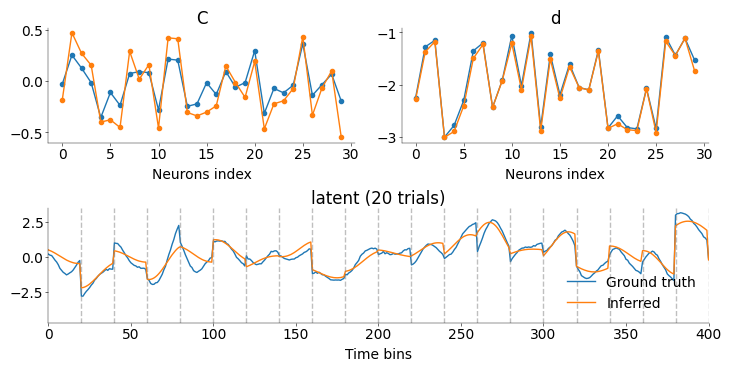

In [ ]:
# ------------------------------------------------------
# Plot ground truth vs. inferred model
# Plot the weights `C`, biases `d` and latent states (2 pts)
# ------------------------------------------------------


# add plot
fig, ax = plt.subplot_mosaic([["C", "d"], ["latent", "latent"]])
# For d & C consider also plotting the optimal weights as a dotted line for reference
ax["C"].plot(init_params["C"], marker=".", color="C0")
ax["C"].plot(fitToy.optimParams["C"], marker=".", color="C1")
ax["C"].set_xlabel("Neurons index")
ax["C"].set_title("C")

ax["d"].plot(init_params["d"], marker=".", color="C0")
ax["d"].plot(fitToy.optimParams["d"], marker=".", color="C1")
ax["d"].set_xlabel("Neurons index")
ax["d"].set_title("d")

# For the latent states consider seperating each trial by a vertical line
# plot only for a subset of trials
ax["latent"].plot(x_true, color="C0", label="Ground truth")
ax["latent"].plot(x_est.T, color="C1", label="Inferred")
ax["latent"].set_xlim(0, 20 * T)

trial_edges = np.arange(0, num_trials * T, T)[1:]
for edge in trial_edges:
    ax["latent"].axvline(edge, linestyle="--", color="gray", alpha=0.5)
ax["latent"].set_xlabel("Time bins")
ax["latent"].set_title("latent (20 trials)")
ax["latent"].legend()

## Task 2: Fit GPFA model to real data. 

We now fit the model to real data and cross-validate over the dimensionality of the latent variable.

*Grading: 4 pts*



### Load data

The cell below implements loading the data and encapsulates it into a class that matches the interface of the Poisson GPFA engine. You don't need to do anything here.

In [ ]:
class EckerDataset:
    """Loosy class"""

    def __init__(
        self,
        path: str,
        subject_id: int = 0,
        ydim: int = 55,
        trialDur: int = 2000,
        binSize: int = 100,
        numTrials: int = 100,
        ydimData: bool = False,
        numTrData: bool = True,
    ):
        # T = binSize #int(trialDur/binSize)
        T = int(trialDur / binSize)
        matdat = sio.loadmat(path)
        self.matdat = matdat
        data = []
        trial_durs = []
        for trial_id in range(numTrials):
            trial_time = matdat["spikeTimes"][:, trial_id][0]
            trial_big_time = np.min(trial_time)
            trial_end_time = np.max(trial_time)
            trial_durs.append(trial_end_time - trial_big_time)
        for trial_id in range(numTrials):
            Y = []
            spike_time = []
            data.append(
                {
                    "Y": matdat["spikeCounts"][:, :, trial_id],  # (ydim, T)
                    "spike_time": matdat["spikeTimes"][
                        :, trial_id
                    ],  # (ydim,) with (num_spikes, 1)
                }
            )
        self.T = T
        self.trial_durs = trial_durs
        self.data = data
        self.trialDur = trialDur
        self.binSize = binSize
        self.numTrials = numTrials
        self.ydim = ydim
        util.dataset.getMeanAndVariance(self)
        util.dataset.getAvgFiringRate(self)
        util.dataset.getAllRaster(self)

In [ ]:
path = "../data/nds_cl_6_data.mat"
data = EckerDataset(path)

### Fit Poisson GPFA models and perform model comparison

Split the data into 80 trials used for training and 20 trials held out for performing model comparison. On the training set, fit models using one to five latent variables. Compute the performance of each model on the held-out test set.

Hint: You can use the `crossValidation` function in the Poisson GPFA package.

Optional: The `crossValidation` function computes the sum of the squared errors (SSE) on the test set, which is not ideal. The predictive log-likelihood under the Poisson model would be a better measure, which you are welcome to compute instead.

### Derivation for log-likelihood

_You can add your calculations in_ $\LaTeX$ _here_.

$p_\lambda(x_t) = \dfrac{\lambda^{x_t}}{x_t!}e^{-\lambda}$: the observed spike counts, `y` in the PGPFA package.

$L(\lambda_k; x_1, ..., x_N) = \prod_{t=1}^N p_{\lambda_k}(x_t) = \prod_{t=1}^N \dfrac{\lambda_k^{x_t}}{x_t!}e^{-\lambda_k}$ 

$log(L) = l(\lambda_k; x_1, ..., x_N) = \sum_{t=1}^N \left(x_t\log \lambda_k -\log x_t! -\lambda_k \right)$

In [ ]:
# training data: fit the params (C, d, tau )with EM-algorithm
# testing data: find the x on the data, then compute the lambda and further error

useMyFunc = False

# import scipy.optimize as op
# import funs.inference as inference


def my_leaveOneOutPrediction(params, experiment):
    """
    Performs leave-one-out prediction with negative log-likelihood as error instead of squared error.
    """
    ydim, xdim = np.shape(params["C"])
    print("\nPerforming leave-one-out cross validation (negative LL)...")
    y_pred_mode_all = []
    pred_err_mode = 0.0
    for tr in range(experiment.numTrials):
        y_pred_mode_tr = []
        for nrn in range(experiment.ydim):
            # Make params without neuron# nrn
            CwoNrn = np.delete(params["C"], nrn, 0)
            dwoNrn = np.delete(params["d"], nrn, 0)
            paramsSplit = {"C": CwoNrn, "d": dwoNrn, "tau": params["tau"]}

            # Make params with only neuron# nrn
            C_nrn = params["C"][nrn]
            d_nrn = params["d"][nrn]

            # Make params big
            C_big, d_big = util.makeCd_big(paramsSplit, experiment.T)
            K_big, K = util.makeK_big(
                paramsSplit, experiment.trialDur, experiment.binSize
            )
            K_bigInv = np.linalg.inv(K_big)

            # Make data without neuron# nrn
            y = np.delete(experiment.data[tr]["Y"], nrn, 0)
            ybar = np.ndarray.flatten(
                np.reshape(y, (experiment.ydim - 1) * experiment.T)
            )

            # to find the x
            xInit = np.ndarray.flatten(np.zeros([xdim * experiment.T, 1]))
            res = op.fmin_ncg(
                f=inference.negLogPosteriorUnNorm,
                x0=xInit,
                fprime=inference.negLogPosteriorUnNorm_grad,
                fhess=inference.negLogPosteriorUnNorm_hess,
                args=(ybar, C_big, d_big, K_bigInv, xdim, experiment.ydim - 1),
                disp=False,
                full_output=True,
            )

            x_post_mode = np.reshape(res[0], [xdim, experiment.T])
            y_pred_mode_nrn = np.exp(
                C_nrn.dot(x_post_mode).T + d_nrn
            )  # predicted `lambda` not the final spike counts `y`

            # pred_err_mode += np.dot(experiment.data[tr]['Y'][nrn]-y_pred_mode_nrn, experiment.data[tr]['Y'][nrn]-y_pred_mode_nrn)   # SE

            # ======= negative log-likelihood =======
            target_y = experiment.data[tr]["Y"][nrn]
            lambda_nrn = np.maximum(y_pred_mode_nrn, 1e-10)
            pred_err_mode += -np.sum(
                target_y * np.log(lambda_nrn) - lambda_nrn
            )  # ignore log(y!)

            y_pred_mode_tr.append(y_pred_mode_nrn)
        y_pred_mode_all.append(y_pred_mode_tr)

    return np.asarray(y_pred_mode_all), pred_err_mode


# override the function
util.leaveOneOutPrediction = my_leaveOneOutPrediction
useMyFunc = True

In [ ]:
# ------------------------------
# Perfom cross validation (1 pt)
# ------------------------------

import os
import pickle

maxXdim = 10  # 5

file_name = "lab6_xval_nll.pkl" if useMyFunc else "lab6_xval_sse.pkl"
file_path = os.path.join("..", "outputs", file_name)
try:
    with open(file_path, "rb") as f:
        xval = pickle.load(f)
    print(f"===== Loaded `{file_path}` =====")
except:
    # do the actual cross validation
    xval = util.crossValidation(
        data, numTrainingTrials=80, numTestTrials=20, maxXdim=maxXdim, maxEMiter=50
    )
    # save to local
    with open(file_path, "wb") as f:
        pickle.dump(xval, f)
    print(f"===== Saved to `{file_path}` =====")

===== Loaded `../outputs/lab6_xval_nll.pkl` =====


### Plot the test error

Make a plot of the test error for the five different models. As a baseline, please also include the test error of a model without a latent variable. This is essentially the SSE of a constant rate model (or Poisson likelihood if you did the optional part above). Note: We assume a constant firing rate across trials, but not necessarily across time.

In [ ]:
# --------------------------------------------------------------------------------
# Compute and plot the test errors for the different latent variable models (1 pt)
# --------------------------------------------------------------------------------

train_set, test_set = util.splitTrainingTestDataset(
    data, numTrainingTrials=80, numTestTrials=20
)

# compute baseline error;p'[]

# the fitted lambda: the mean number of spikes on training
Y_train_all = np.array([trial["Y"] for trial in train_set.data])  # shape: (80, ydim, T)
lambda_baseline = np.mean(Y_train_all, axis=0)  # shape: (ydim, T)
lambda_baseline = np.maximum(lambda_baseline, 1e-10)  # to prevent log(0)

baseline_error = 0.0
if useMyFunc:
    for trial in test_set.data:
        y_test = trial["Y"]  # shape: (ydim, T)
        baseline_error += -np.sum(y_test * np.log(lambda_baseline) - lambda_baseline)
    print(f"Baseline Error (NLL): {baseline_error}")
else:
    for trial in test_set.data:
        y_test = trial["Y"]  # shape: (ydim, T)
        baseline_error += np.sum((y_test - lambda_baseline) ** 2)
    print(f"Baseline Error (SSE): {baseline_error}")

Baseline Error (NLL): 7634.956500994942


The best model: 4 latent variables


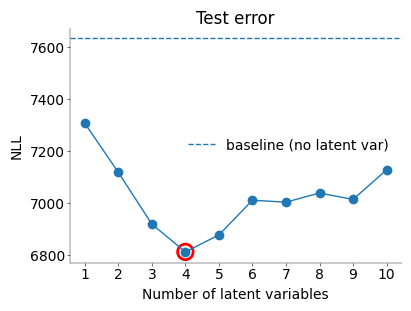

In [ ]:
# -------------------------------------------------------------------------
# Compute and plot the test errors for the different latent variable models
# and answer the questions below (1+1 pts)
# -------------------------------------------------------------------------

xdim_list = np.arange(1, maxXdim + 1)
# Your plot here
fig, ax = plt.subplots(figsize=(4, 3))

# plot model error
ax.plot(xdim_list, xval.errs, marker="o")
ax.set_xticks(xdim_list)
ax.set_xlabel("Number of latent variables")
ax.set_title("Test error")
if useMyFunc:
    ax.set_ylabel("NLL")
else:
    ax.set_ylabel("SSE")

print(f"The best model: {xval.optimXdim} latent variables")
ax.scatter(
    xval.optimXdim,
    xval.errs[xval.optimXdim - 1],
    s=500,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
)

# plot baseline
ax.axhline(baseline_error, linestyle="--", label="baseline (no latent var)")
plt.legend()
plt.show()

### Questions

Is the baseline error (0 latents) about what you expect in relation to the other models? Why or why not?

> Yes. The baseline uses only the average firing rate for each neuron and time bin, so it cannot explain trial-to-trial co-fluctuations shared across neurons. A GPFA model with latent variables should therefore reduce the held-out error if the population has shared variability beyond the time-dependent mean. If the baseline is close to or better than the latent models, the fitted latents are either not adding predictive structure or the EM fit/cross-validation has not converged enough.

Can you identify a "best model". If so, which is it and what does this say about the structure of the latent state?

> The best model is the dimensionality with the smallest held-out error in the plot above (4 latent variables), stored as best_xdim. If this minimum is at a low dimensionality and the curve flattens afterwards, it means most shared population variability is captured by a low-dimensional latent state; additional latents mainly fit smaller residual structure or noise.

## Task 3. Visualization: population rasters and latent state.
Use the model with a single latent state. 

Create a raster plot where you show for each trial the spikes of all neurons as well as the trajectory of the latent state `x` (take care of the correct time axis). Sort the neurons by their weights `c_k`. Plot only the first 20 trials.

*Grading: 2 pts*

/var/folders/ty/jw9csq0j64j3_w_b8kmz3b2h0000gn/T/ipykernel_63914/3673755452.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


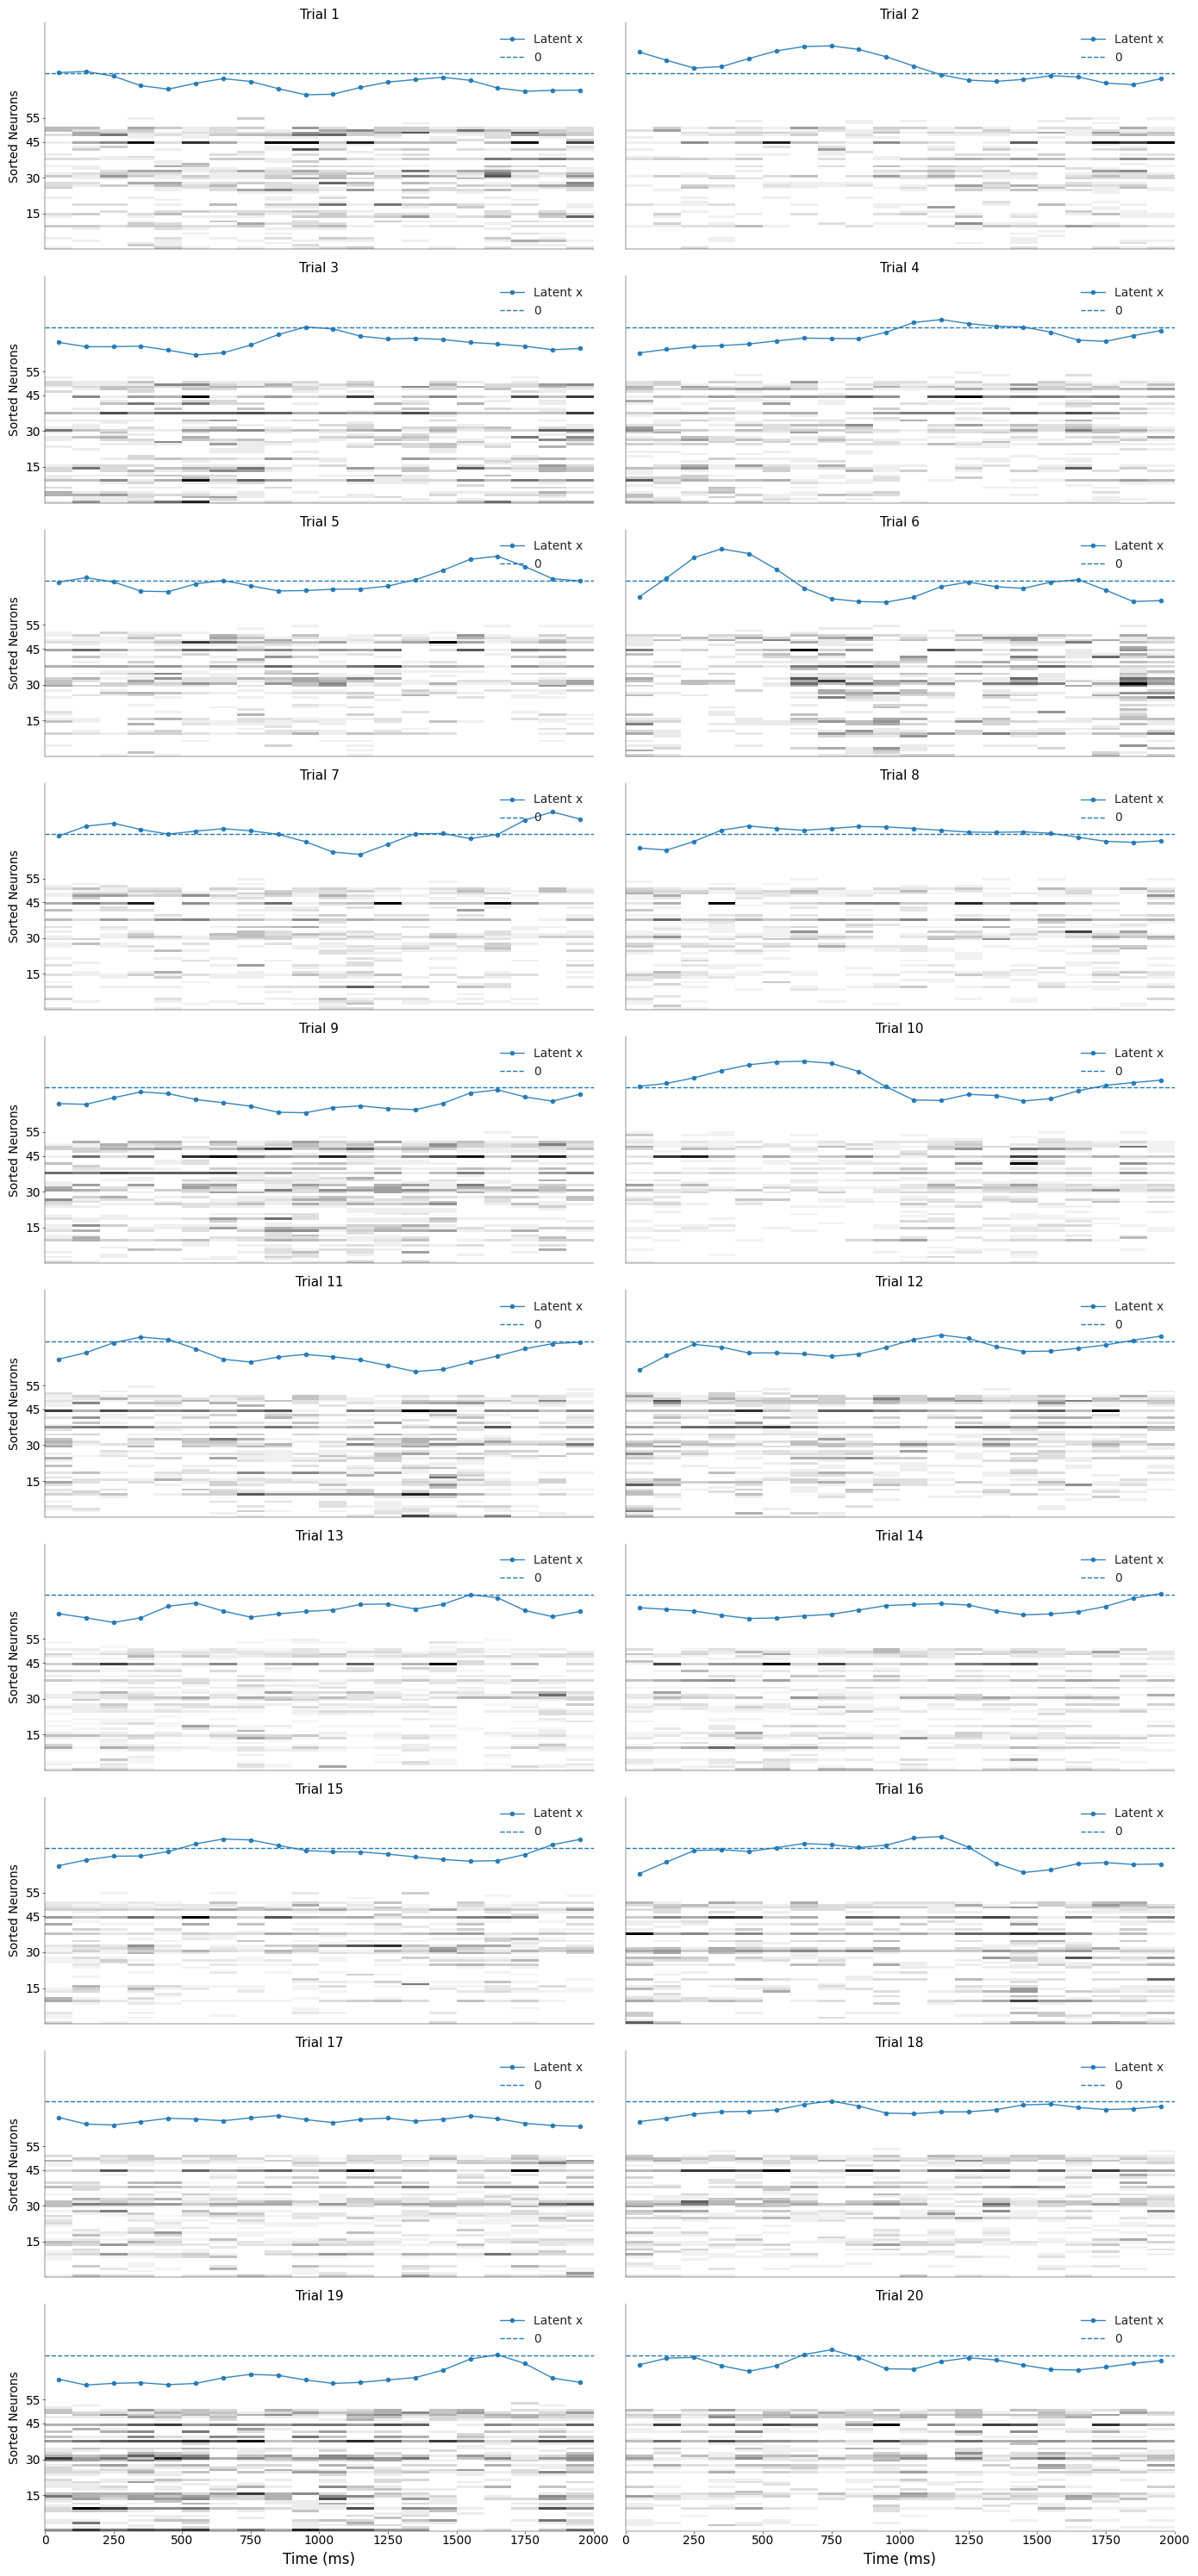

In [ ]:
# Your plot here
fig, axs = plt.subplots(10, 2, figsize=(14, 30))

fit1 = xval.fits[0]  # pick the model with a single latent state

C_k = fit1.optimParams["C"][:, 0]
sorting_indices = np.argsort(C_k)  # ascending sorting

# Calculate global min/max for latent states to scale them consistently across all subplots
all_x = allTrialsState(fit1, 1).reshape(
    (80, int(T))
)  # (num_trials, T) only 80 trials (training before)
x_min, x_max = all_x.min(), all_x.max()
x_range = x_max - x_min if x_max > x_min else 1
# Display settings for the curve above the raster
curve_height = 30  # The amplitude space for the curve
margin = 5  # Space between raster and curve
y_offset = data.ydim + margin

ts = np.arange(data.binSize / 2, data.trialDur, data.binSize)

with sns.axes_style("ticks"):
    for ntrial, ax in enumerate(axs.flat):

        # --------------------------------------------------------
        # plot the raster for each neuron and latent state (2 pts)
        # --------------------------------------------------------

        # hint: can be plotted on top of the corresponding raster

        # ==== Raster plot (spike counts of all neurons) ===

        # spike_count sorted by neurons' `c` (neurons with larger index holds a larger c (signed))
        y_binned = data.data[ntrial]["Y"][sorting_indices, :]
        ax.imshow(
            y_binned,
            extent=[0, data.trialDur, 0, data.ydim],
            cmap="gray_r",
            aspect="auto",
            origin="lower",  # number starts from lower side
            interpolation="nearest",  # avoid blurriness in discrete data
        )

        # ==== Curve plot (latent trajectories) ====

        # Scale x_est globally and shift it ABOVE the raster plot area
        x_est = all_x[ntrial, :]  # (T,)
        x_scaled = (x_est - x_min) / x_range * curve_height + y_offset
        ax.plot(
            ts,
            x_scaled,
            alpha=0.9,
            marker=".",
            label="Latent x",
        )
        ax.axhline(
            -x_min / x_range * curve_height + y_offset,
            linestyle="--",
            label="0",
        )

        ax.set_yticks([15, 30, 45, 55])
        ax.set_ylim([0, y_offset + curve_height + margin])
        ax.set_xlim([0, data.trialDur])
        ax.set_title(f"Trial {ntrial+1}", fontsize=11, pad=3)
        ax.legend(loc="upper right", framealpha=0.9, fontsize=10)

        if ntrial >= 18:  # Bottom row
            ax.set_xlabel("Time (ms)", fontsize=12)
        else:
            ax.set_xticks([])

        if ntrial % 2 == 0:  # Left column
            ax.set_ylabel("Sorted Neurons")
        else:
            ax.set_yticks([])

plt.tight_layout()
plt.savefig(
    os.path.join(
        "..", "outputs", f"Lab6_rasterplot_{'nll' if useMyFunc else 'sse'}.png"
    )
)
plt.show()

## Task 4. Visualization of covariance matrix.

Plot (a) the covariance matrix of the observed data as well as its approximation using (b) one and (c) five latent variable(s). Use the analytical solution for the covariance matrix of the approximation*. Note that the solution is essentially the mean and covariance of the [log-normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution).

$\mu = \exp(\frac{1}{2} \text{diag}(CC^T)+d)$

$\text{Cov}= \mu\otimes\mu^T \odot \exp(CC^T)+\mu\cdot \mathbb{I} - \mu\otimes\mu^T$ 

*[Krumin, M., and Shoham, S. (2009). Generation of Spike Trains with Controlled Auto- and Cross-Correlation Functions. Neural Computation 21, 1642–1664](http://www.mitpressjournals.org/doi/10.1162/neco.2009.08-08-847).

*Grading: 3 pts*

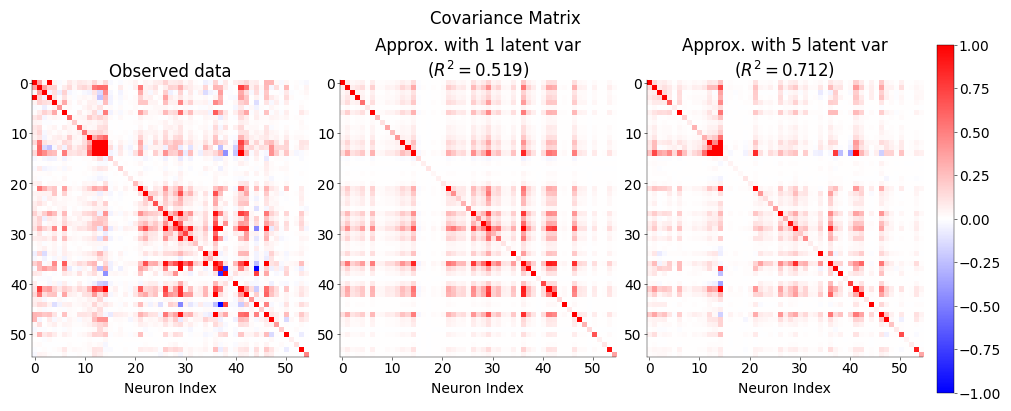

In [ ]:
# --------------------------------------------------------------
# Complete the analytical solution for the covariance matrix of
# the approximation using the provide equations (2 pts)
# --------------------------------------------------------------


def calc_off_diag_r2(cov_obs, cov_approx):
    """
    Compute the R^2 coefficient (square of Pearson correlation coefficient) for the off-diagnal parts between two covariance matrix (only the uppper part).
    """
    row_idx, col_idx = np.triu_indices_from(cov_obs, k=1)

    obs_off_diag = cov_obs[row_idx, col_idx]
    approx_off_diag = cov_approx[row_idx, col_idx]

    corr_matrix = np.corrcoef(obs_off_diag, approx_off_diag)
    r2 = corr_matrix[0, 1] ** 2

    return r2


def cov(fit: engine.PPGPFAfit):
    C = fit.optimParams["C"]  # (ydim, xdim)
    d = fit.optimParams["d"]  # (ydim,)

    mu = np.exp(np.diag(C @ C.T) / 2 + d)  # (ydim,)
    outer_mu = np.outer(mu, mu)
    c = outer_mu * np.exp(C @ C.T) + np.diag(mu) - outer_mu  # (ydim, ydim)

    return c, mu


# --------------------------------------------------------------
# Plot the covariance matrix of
# (1) the observed data
# (2) its approximation using 1 latent variable
# (3) its approximation using 5 latent variable
# and explain how they compare (1+1 pts).
# --------------------------------------------------------------

obs_corr = np.cov(data.all_raster)
opt_r1, mu1 = cov(xval.fits[0])
opt_r5, mu5 = cov(xval.fits[4])

# HINT: Think about which type of colormap and ranges are appropriate here.

fig, axs = plt.subplots(1, 3, figsize=(10, 4))
# add plot to visualize the differences in the covariance matrices

# vlim_0 = np.max(np.abs(obs_corr))
# vlim_1 = np.max(np.abs(opt_r1))
# vlim_2 = np.max(np.abs(opt_r5))
vlim = 1

im0 = axs[0].imshow(obs_corr, cmap="bwr", vmin=-vlim, vmax=vlim)
im1 = axs[1].imshow(opt_r1, cmap="bwr", vmin=-vlim, vmax=vlim)
im2 = axs[2].imshow(opt_r5, cmap="bwr", vmin=-vlim, vmax=vlim)

for i in range(3):
    axs[i].set_xlabel("Neuron Index")

# fig.colorbar(im0, ax=axs[0])
# fig.colorbar(im1, ax=axs[1])
fig.colorbar(im2, ax=axs[2])

r2_1 = calc_off_diag_r2(obs_corr, opt_r1)
r2_5 = calc_off_diag_r2(obs_corr, opt_r5)

axs[0].set_title("Observed data")
axs[1].set_title(f"Approx. with 1 latent var\n($R^2={r2_1:.3f}$)")
axs[2].set_title(f"Approx. with 5 latent var\n($R^2={r2_5:.3f}$)")

plt.suptitle("Covariance Matrix")
plt.show()

### Questions

What do you see / expect to see?

> The observed covariance should show a strong diagonal from each neuron's own spike-count variance plus structured off-diagonal covariance from shared population fluctuations. The one-latent approximation can only express a relatively simple shared covariance pattern, so it captures the dominant co-fluctuation but misses finer structure. The five-latent approximation has enough dimensions to represent a richer covariance matrix and should more closely resemble the observed covariance, especially in the off-diagonal blocks.